<a href="https://colab.research.google.com/github/abdullahalmusabbir/Deep-Learning-Project/blob/main/FDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import flwr as fl
from tensorflow.keras.utils import to_categorical

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [2]:
path = kagglehub.dataset_download("fedesoriano/cifar10-python-in-csv")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cifar10-python-in-csv' dataset.
Path to dataset files: /kaggle/input/cifar10-python-in-csv


In [3]:
# The dataset provides train and test CSVs
train_df = pd.read_csv(f"{path}/train.csv")
test_df = pd.read_csv(f"{path}/test.csv")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [4]:
# Split features and labels
X = train_df.drop("label", axis=1)
y = train_df["label"]

# Split training data for demonstration purposes
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Convert labels to categorical
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)
y_val = to_categorical(y_val, num_classes=10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
X_train = X_train.values.reshape(-1, 32, 32, 3) / 255.0
X_test = X_test.values.reshape(-1, 32, 32, 3) / 255.0

In [6]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [7]:
def create_model():
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer="adam",
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model

In [8]:
client_data = []
num_clients = 5
split_size = len(X_train) // num_clients

for i in range(num_clients):
    start = i * split_size
    end = (i+1) * split_size
    client_data.append((X_train[start:end], y_train[start:end]))

In [9]:
class CifarClient(fl.client.NumPyClient):
    def __init__(self, model, train_data, test_data):
        self.model = model
        self.x_train, self.y_train = train_data
        self.x_test, self.y_test = test_data

    def get_parameters(self, config):
        return self.model.get_weights()

    def fit(self, parameters, config):
        self.model.set_weights(parameters)
        self.model.fit(self.x_train, self.y_train, epochs=1, batch_size=32, verbose=0)
        return self.model.get_weights(), len(self.x_train), {}

    def evaluate(self, parameters, config):
        self.model.set_weights(parameters)
        loss, accuracy = self.model.evaluate(self.x_test, self.y_test, verbose=0)
        return loss, len(self.x_test), {"accuracy": accuracy}


In [10]:
def client_fn(cid: str):
    """Return a Flower client representing a single federated client."""
    model = create_model()
    train_data = client_data[int(cid)]
    test_data = (X_test, y_test)
    return CifarClient(model, train_data, test_data)

# Run federated simulation with 5 clients and 3 rounds
strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,  # All clients participate
    fraction_evaluate=1.0,
    min_fit_clients=5,
    min_evaluate_clients=5,
    min_available_clients=5,
)

fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=num_clients,
    config=fl.server.ServerConfig(num_rounds=3),
    strategy=strategy,
)

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=3, no round_timeout
2025-09-22 05:38:09,213	INFO worker.py:1771 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [12]:
import matplotlib.pyplot as plt

# List to store results
round_acc = []
round_loss = []

# Custom strategy with metrics collection
class SaveMetricsStrategy(fl.server.strategy.FedAvg):
    def aggregate_evaluate(self, rnd, results, failures):
        aggregated_loss, aggregated_metrics = super().aggregate_evaluate(rnd, results, failures) or (None, {})
        if aggregated_loss is not None:
            round_loss.append(aggregated_loss)
        if aggregated_metrics and "accuracy" in aggregated_metrics:
            round_acc.append(aggregated_metrics["accuracy"])
        return aggregated_loss, aggregated_metrics

# Use the custom strategy
strategy = SaveMetricsStrategy(
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=5,
    min_evaluate_clients=5,
    min_available_clients=5,
)

fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=num_clients,
    config=fl.server.ServerConfig(num_rounds=3),
    strategy=strategy,
)

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=3, no round_timeout
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
2025-09-22 05:50:26,241	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'CPU': 2.0, 'memory': 7986841191.0, 'nod

(raylet) A worker died or was killed while executing a task by an unexpected system error. To troubleshoot the problem, check the logs for the dead worker. RayTask ID: ffffffffffffffffc46835cbd844adb374cf231f01000000 Worker ID: ac3ee4c0ed5c31d04f88d3d2b2c857856760ea8424bfdb8b926c430a Node ID: e53e6c42de38ecbd74e6964a55d9ea1a3e121e9e1e62980bae4902cb Worker IP address: 172.28.0.12 Worker port: 44985 Worker PID: 10421 Worker exit type: SYSTEM_ERROR Worker exit detail: Worker unexpectedly exits with a connection error code 2. End of file. There are some potential root causes. (1) The process is killed by SIGKILL by OOM killer due to high memory usage. (2) ray stop --force is called. (3) The worker is crashed unexpectedly due to SIGSEGV or other unexpected errors.


(ClientAppActor pid=10421) WARNING :   Deprecation Warning: The `client_fn` function must return an instance of `Client`, but an instance of `NumpyClient` was returned. Please use `NumPyClient.to_client()` method to convert it to `Client`.
ERROR :     The actor died unexpectedly before finishing this task.
	class_name: ClientAppActor
	actor_id: c46835cbd844adb374cf231f01000000
	pid: 10421
	namespace: 881aa4b9-8c5f-473c-a44c-ded7c35b20f9
	ip: 172.28.0.12
The actor is dead because its worker process has died. Worker exit type: SYSTEM_ERROR Worker exit detail: Worker unexpectedly exits with a connection error code 2. End of file. There are some potential root causes. (1) The process is killed by SIGKILL by OOM killer due to high memory usage. (2) ray stop --force is called. (3) The worker is crashed unexpectedly due to SIGSEGV or other unexpected errors.
ERROR :     The actor died unexpectedly before finishing this task.
	class_name: ClientAppActor
	actor_id: c46835cbd844adb374cf231f01000

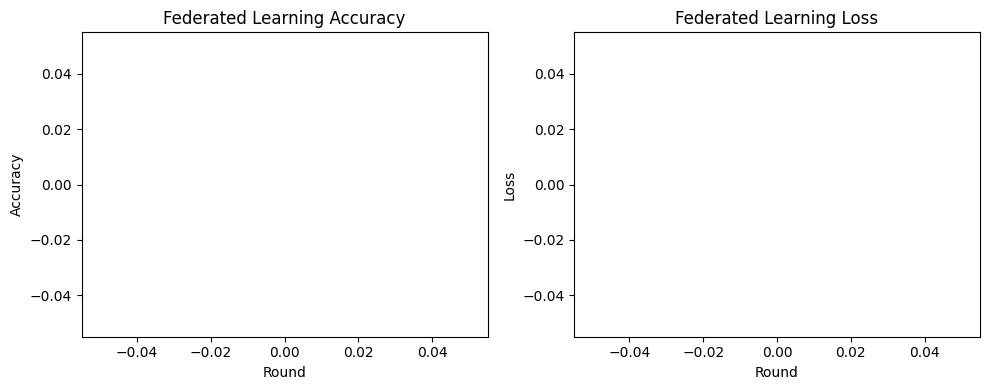

In [13]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(range(1, len(round_acc)+1), round_acc, marker='o')
plt.title("Federated Learning Accuracy")
plt.xlabel("Round")
plt.ylabel("Accuracy")

plt.subplot(1,2,2)
plt.plot(range(1, len(round_loss)+1), round_loss, marker='o', color='red')
plt.title("Federated Learning Loss")
plt.xlabel("Round")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()